# Hoja de trabajo 2. Transformers y mecanismos de atención

CC3092 Deep Learning y Sistemas Inteligentes. Brandon Werner Rivera Cabrera 23088

1. Implementación de scaled dot-product attention y multi-head attention desde cero, con un ejercicio a mano y verificaciones contra PyTorch.
2. Escalamiento del costo de la atención con la longitud de la secuencia.
3. Visualización y análisis de la atención de BERT (`bert-base-uncased`) y GPT-2 (`gpt2`): patrones por cabeza, correferencia de «it», máscara causal y attention sinks, entropía por capa, importancia de cada cabeza y comparación de la atención con la saliencia por gradiente.

**Cómo se ejecuta.** Corre de principio a fin con `jupyter nbconvert --execute`. Los resultados quedan en `results/` y las figuras en `figs/`. Los benchmarks usan la GPU de la Mac (MPS) si está disponible; los análisis de BERT y GPT-2 corren en CPU.

## 0. Configuración

In [1]:
import os, json, math, time, platform, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.stats import spearmanr
import transformers
from transformers import AutoTokenizer, AutoModel, AutoModelForCausalLM

warnings.filterwarnings("ignore")
SMOKE = os.environ.get("HT2_SMOKE") == "1"      # prueba rápida con modelos pequeños, solo para verificar que corre
torch.manual_seed(0); np.random.seed(0)
if torch.backends.mps.is_available():
    DISP = torch.device("mps")
elif torch.cuda.is_available():
    DISP = torch.device("cuda")
else:
    DISP = torch.device("cpu")

def sincronizar():
    if DISP.type == "mps": torch.mps.synchronize()
    elif DISP.type == "cuda": torch.cuda.synchronize()

for d in ["figs", "results"]:
    os.makedirs(d, exist_ok=True)
entorno = {"sistema": platform.platform(), "procesador": platform.processor() or platform.machine(),
           "python": platform.python_version(), "torch": torch.__version__, "transformers": transformers.__version__,
           "dispositivo_benchmarks": str(DISP), "smoke": SMOKE}
json.dump(entorno, open("results/entorno.json", "w"), indent=2)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})
AZUL, NARANJA, VERDE, MORADO, GRIS, ROJO = "#2a78d6", "#eb6834", "#1baf7a", "#8a5cd1", "#5f5e5a", "#d1495b"
print(json.dumps(entorno, indent=2))

{
  "sistema": "macOS-26.3.1-arm64-arm-64bit-Mach-O",
  "procesador": "arm",
  "python": "3.13.5",
  "torch": "2.13.0",
  "transformers": "5.18.0",
  "dispositivo_benchmarks": "mps",
  "smoke": false
}


## 1. Atención desde cero

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

La máscara es booleana con `True` en las posiciones que sí pueden atenderse, la misma convención de `F.scaled_dot_product_attention`. Las posiciones prohibidas reciben $-\infty$ antes de la softmax, así que su peso queda exactamente en cero.

In [2]:
def atencion(Q, K, V, mascara=None):
    d_k = Q.shape[-1]
    puntajes = Q @ K.transpose(-2, -1) / math.sqrt(d_k)          # (..., n, m)
    if mascara is not None:
        puntajes = puntajes.masked_fill(~mascara, float("-inf"))
    pesos = torch.softmax(puntajes, dim=-1)                        # cada fila suma 1
    return pesos @ V, pesos

class AtencionMultiCabeza(nn.Module):
    # h cabezas de dimensión d_model / h: proyecta, divide en cabezas, atiende y concatena
    def __init__(self, d_model, h):
        super().__init__()
        assert d_model % h == 0
        self.h, self.d = h, d_model // h
        self.Wq, self.Wk, self.Wv, self.Wo = (nn.Linear(d_model, d_model) for _ in range(4))

    def forward(self, x_q, x_kv=None, padding=None, mascara=None):
        x_kv = x_q if x_kv is None else x_kv                       # self-attention si no hay x_kv
        B, n, _ = x_q.shape; m = x_kv.shape[1]
        dividir = lambda t, L: t.view(B, L, self.h, self.d).transpose(1, 2)   # (B, h, L, d)
        q, k, v = dividir(self.Wq(x_q), n), dividir(self.Wk(x_kv), m), dividir(self.Wv(x_kv), m)
        permitido = torch.ones(B, 1, n, m, dtype=torch.bool, device=x_q.device)
        if padding is not None:                                    # padding True = posición a ignorar
            permitido = permitido & ~padding[:, None, None, :]
        if mascara is not None:
            permitido = permitido & mascara
        salida, pesos = atencion(q, k, v, permitido)
        salida = salida.transpose(1, 2).reshape(B, n, self.h * self.d)
        return self.Wo(salida), pesos

### 1.1 Ejercicio a mano

Tres tokens con $d_k = 2$ y $Q = K$. Se imprimen todos los pasos para seguirlos a mano: productos punto, escalamiento por $\sqrt{2}$, softmax por fila y combinación de los valores. Después se repite con máscara causal.

In [3]:
Qm = torch.tensor([[1., 0.], [0., 1.], [1., 1.]])
Km = Qm.clone()
Vm = torch.tensor([[1., 2.], [3., 4.], [5., 6.]])
torch.set_printoptions(precision=4, sci_mode=False)
pasos = {}
pasos["QK^T"] = Qm @ Km.T
pasos["QK^T / sqrt(2)"] = pasos["QK^T"] / math.sqrt(2)
pasos["exp"] = torch.exp(pasos["QK^T / sqrt(2)"])
pasos["softmax"] = pasos["exp"] / pasos["exp"].sum(-1, keepdim=True)
pasos["salida"] = pasos["softmax"] @ Vm
causal = torch.tril(torch.ones(3, 3, dtype=torch.bool))
salida_c, pesos_c = atencion(Qm, Km, Vm, causal)
pasos["softmax causal"] = pesos_c
pasos["salida causal"] = salida_c
for k, v in pasos.items():
    print(f"{k}:\n{v}\n")
salida_f, pesos_f = atencion(Qm, Km, Vm)
print("coincide con la función atencion:", torch.allclose(salida_f, pasos["salida"]))
json.dump({k: v.tolist() for k, v in pasos.items()}, open("results/ejercicio_a_mano.json", "w"), indent=1)

QK^T:
tensor([[1., 0., 1.],
        [0., 1., 1.],
        [1., 1., 2.]])

QK^T / sqrt(2):
tensor([[0.7071, 0.0000, 0.7071],
        [0.0000, 0.7071, 0.7071],
        [0.7071, 0.7071, 1.4142]])

exp:
tensor([[2.0281, 1.0000, 2.0281],
        [1.0000, 2.0281, 2.0281],
        [2.0281, 2.0281, 4.1133]])

softmax:
tensor([[0.4011, 0.1978, 0.4011],
        [0.1978, 0.4011, 0.4011],
        [0.2483, 0.2483, 0.5035]])

salida:
tensor([[3.0000, 4.0000],
        [3.4067, 4.4067],
        [3.5105, 4.5105]])

softmax causal:
tensor([[1.0000, 0.0000, 0.0000],
        [0.3302, 0.6698, 0.0000],
        [0.2483, 0.2483, 0.5035]])

salida causal:
tensor([[1.0000, 2.0000],
        [2.3395, 3.3395],
        [3.5105, 4.5105]])

coincide con la función atencion: True


### 1.2 Verificaciones

1. La función propia contra `F.scaled_dot_product_attention`, sin máscara, con `is_causal=True` y con una máscara booleana arbitraria.
2. La multi-head propia contra `nn.MultiheadAttention` con los mismos pesos, incluyendo `key_padding_mask` y los pesos por cabeza y promediados.
3. El número de parámetros de multi-head attention no depende del número de cabezas.
4. Si $q$ y $k$ tienen componentes independientes de media 0 y varianza 1, $\text{Var}(q\cdot k) = d_k$; al dividir entre $\sqrt{d_k}$ vuelve a 1.
5. Sin escalamiento la softmax se satura y su jacobiano se anula.
6. La self-attention sin codificación posicional es equivariante a permutaciones.
7. Propiedades de la codificación sinusoidal y de la máscara causal de PyTorch.
8. Normas de gradiente por capa con Post-LN y Pre-LN.

In [4]:
V_ = {}
torch.manual_seed(0)
B, h, n, d = 2, 4, 10, 16
Q, K, Vv = torch.randn(B, h, n, d), torch.randn(B, h, n, d), torch.randn(B, h, n, d)
o_propio, _ = atencion(Q, K, Vv)
V_["sdpa_sin_mascara"] = float((o_propio - F.scaled_dot_product_attention(Q, K, Vv)).abs().max())
tril = torch.tril(torch.ones(n, n, dtype=torch.bool))
o_propio_c, w_c = atencion(Q, K, Vv, tril)
V_["sdpa_causal"] = float((o_propio_c - F.scaled_dot_product_attention(Q, K, Vv, is_causal=True)).abs().max())
m_aleatoria = torch.rand(n, n) > 0.5
m_aleatoria |= torch.eye(n, dtype=torch.bool)                # cada fila con al menos una posición permitida
V_["sdpa_mascara_booleana"] = float((atencion(Q, K, Vv, m_aleatoria)[0] - F.scaled_dot_product_attention(Q, K, Vv, attn_mask=m_aleatoria)).abs().max())
V_["pesos_causales_arriba_de_la_diagonal"] = float(w_c.triu(1).abs().max())

# multi-head propia contra nn.MultiheadAttention con los mismos pesos
d_model, H = 32, 4
torch.manual_seed(1)
mha = nn.MultiheadAttention(d_model, H, batch_first=True)
propia = AtencionMultiCabeza(d_model, H)
with torch.no_grad():
    for i, lin in enumerate([propia.Wq, propia.Wk, propia.Wv]):
        lin.weight.copy_(mha.in_proj_weight[i * d_model:(i + 1) * d_model])
        lin.bias.copy_(mha.in_proj_bias[i * d_model:(i + 1) * d_model])
    propia.Wo.weight.copy_(mha.out_proj.weight); propia.Wo.bias.copy_(mha.out_proj.bias)
x = torch.randn(2, 7, d_model)
padding = torch.zeros(2, 7, dtype=torch.bool); padding[1, -3:] = True
o_ref, w_ref = mha(x, x, x, key_padding_mask=padding, need_weights=True, average_attn_weights=False)
o_pro, w_pro = propia(x, padding=padding)
V_["mha_salida"] = float((o_ref - o_pro).abs().max())
V_["mha_pesos_por_cabeza"] = float((w_ref - w_pro).abs().max())
_, w_prom = mha(x, x, x, key_padding_mask=padding, average_attn_weights=True)
V_["mha_pesos_promediados"] = float((w_prom - w_pro.mean(1)).abs().max())
V_["mha_peso_a_padding"] = float(w_pro[1, :, :, -3:].abs().max())

# parámetros contra número de cabezas
V_["parametros_por_cabezas"] = {h_: sum(p.numel() for p in nn.MultiheadAttention(512, h_).parameters()) for h_ in [1, 2, 4, 8, 16]}
V_["parametros_formula_4d2_4d"] = 4 * 512 ** 2 + 4 * 512
for k, v in V_.items():
    print(f"{k:40s} {v}")

sdpa_sin_mascara                         3.5762786865234375e-07
sdpa_causal                              3.5762786865234375e-07
sdpa_mascara_booleana                    3.5762786865234375e-07
pesos_causales_arriba_de_la_diagonal     0.0
mha_salida                               1.1920928955078125e-07
mha_pesos_por_cabeza                     8.940696716308594e-08
mha_pesos_promediados                    2.9802322387695312e-08
mha_peso_a_padding                       0.0
parametros_por_cabezas                   {1: 1050624, 2: 1050624, 4: 1050624, 8: 1050624, 16: 1050624}
parametros_formula_4d2_4d                1050624


In [5]:
# varianza del producto punto y saturación de la softmax
torch.manual_seed(2)
filas_var, filas_sat = [], []
for d_k in [4, 16, 64, 256, 1024]:
    q, k = torch.randn(100_000, d_k), torch.randn(100_000, d_k)
    pp = (q * k).sum(-1)
    filas_var.append({"d_k": d_k, "var_qk": float(pp.var()), "var_qk_escalado": float((pp / math.sqrt(d_k)).var())})
    q, Kk = torch.randn(2000, d_k), torch.randn(32, d_k)
    for escalar in [False, True]:
        z = (q @ Kk.T) / (math.sqrt(d_k) if escalar else 1.0)
        p = torch.softmax(z, -1)
        jac = (p ** 2).sum(-1) - 2 * (p ** 3).sum(-1) + ((p ** 2).sum(-1)) ** 2     # ||diag(p) - pp^T||_F^2
        filas_sat.append({"d_k": d_k, "escalado": escalar, "peso_maximo": float(p.max(-1).values.mean()),
                          "entropia": float(-(p * torch.log(p.clamp_min(1e-12))).sum(-1).mean()),
                          "norma_jacobiano": float(jac.clamp_min(0).sqrt().mean())})
tabla_var, tabla_sat = pd.DataFrame(filas_var), pd.DataFrame(filas_sat)
tabla_var.to_csv("results/varianza_producto_punto.csv", index=False)
tabla_sat.to_csv("results/saturacion_softmax.csv", index=False)
print(tabla_var.round(3).to_string(index=False))
print(f"\nentropía máxima con 32 llaves: log(32) = {math.log(32):.3f}")
print(tabla_sat.round(4).to_string(index=False))

 d_k   var_qk  var_qk_escalado
   4    4.009            1.002
  16   16.039            1.002
  64   64.093            1.001
 256  256.038            1.000
1024 1022.531            0.999

entropía máxima con 32 llaves: log(32) = 3.466
 d_k  escalado  peso_maximo  entropia  norma_jacobiano
   4     False       0.4160    2.0935           0.2828
   4      True       0.1875    2.9811           0.2400
  16     False       0.6212    1.1637           0.2922
  16      True       0.1575    3.0399           0.2371
  64     False       0.8138    0.5051           0.1939
  64      True       0.1636    3.0188           0.2404
 256     False       0.9101    0.2280           0.1116
 256      True       0.1648    3.0115           0.2413
1024     False       0.9559    0.1081           0.0598
1024      True       0.1644    3.0158           0.2410


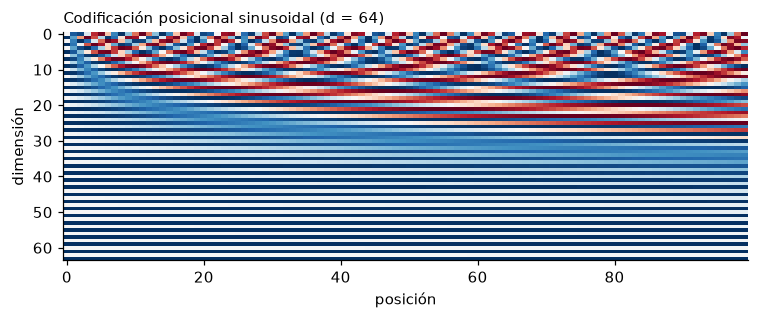

pe_producto_desfase_1_desv_est             9.546474470410234e-15
pe_producto_desfase_5_desv_est             6.4027746737274416e-15
pe_producto_desfase_20_desv_est            8.094801292007203e-15
pe_rotacion_error                          2.248201624865942e-14
permutacion_sin_pe                         5.960464477539063e-08
permutacion_con_pe                         0.07915936410427094
mascara_generate_square_subsequent_mask    [[0.0, -inf, -inf, -inf], [0.0, 0.0, -inf, -inf], [0.0, 0.0, 0.0, -inf], [0.0, 0.0, 0.0, 0.0]]


In [6]:
# codificación posicional sinusoidal y equivarianza a permutaciones
def pe_sinusoidal(n, d):
    pos = torch.arange(n, dtype=torch.float64)[:, None]
    i = torch.arange(0, d, 2, dtype=torch.float64)
    ang = pos / (10000 ** (i / d))
    pe = torch.zeros(n, d, dtype=torch.float64)
    pe[:, 0::2], pe[:, 1::2] = torch.sin(ang), torch.cos(ang)
    return pe

PE = pe_sinusoidal(256, 64)
for k in [1, 5, 20]:
    prod = (PE[:-k] * PE[k:]).sum(1)
    V_[f"pe_producto_desfase_{k}_desv_est"] = float(prod.std())
# PE(p + k) es una rotación fija de PE(p): bloques 2x2 con ángulo k * w_i
k = 7
w = 1 / (10000 ** (torch.arange(0, 64, 2, dtype=torch.float64) / 64))
seno, coseno = PE[:-k, 0::2], PE[:-k, 1::2]
rot_seno = seno * torch.cos(k * w) + coseno * torch.sin(k * w)
rot_coseno = coseno * torch.cos(k * w) - seno * torch.sin(k * w)
V_["pe_rotacion_error"] = float(max((rot_seno - PE[k:, 0::2]).abs().max(), (rot_coseno - PE[k:, 1::2]).abs().max()))

torch.manual_seed(3)
capa = AtencionMultiCabeza(32, 4)
X = torch.randn(1, 6, 32)
perm = torch.randperm(6)
with torch.no_grad():
    sin_pe = capa(X[:, perm])[0] - capa(X)[0][:, perm]
    pe6 = pe_sinusoidal(6, 32).float()[None]
    con_pe = capa(X[:, perm] + pe6)[0] - capa(X + pe6)[0][:, perm]
V_["permutacion_sin_pe"] = float(sin_pe.abs().max())
V_["permutacion_con_pe"] = float(con_pe.abs().max())
V_["mascara_generate_square_subsequent_mask"] = nn.Transformer.generate_square_subsequent_mask(4).tolist()

fig, ax = plt.subplots(figsize=(7, 3))
ax.imshow(PE[:100].T.numpy(), aspect="auto", cmap="RdBu")
ax.set_xlabel("posición"); ax.set_ylabel("dimensión"); ax.grid(False)
ax.set_title("Codificación posicional sinusoidal (d = 64)", loc="left", fontsize=10)
fig.tight_layout(); fig.savefig("figs/codificacion_posicional.png", bbox_inches="tight"); plt.show()
for k_, v in V_.items():
    if k_.startswith(("pe_", "permutacion", "mascara")):
        print(f"{k_:42s} {v}")

In [7]:
# Post-LN frente a Pre-LN: norma del gradiente de cada capa al inicializar
def normas_por_capa(norm_first, capas=12):
    torch.manual_seed(4)
    enc = nn.TransformerEncoder(nn.TransformerEncoderLayer(64, 4, 128, dropout=0.0, batch_first=True, norm_first=norm_first),
                                num_layers=capas, enable_nested_tensor=False,
                                norm=nn.LayerNorm(64) if norm_first else None)   # Pre-LN lleva una LayerNorm final, como GPT-2
    x, y = torch.randn(8, 20, 64), torch.randn(8, 20, 64)
    (enc(x) - y).pow(2).mean().backward()                   # MSE contra un objetivo aleatorio
    return [float(torch.sqrt(sum(p.grad.pow(2).sum() for p in l.parameters()))) for l in enc.layers]
ln = pd.DataFrame({"capa": range(1, 13), "post_ln": normas_por_capa(False), "pre_ln": normas_por_capa(True)})
ln.to_csv("results/normas_gradiente_ln.csv", index=False)
V_["post_ln_ultima_sobre_primera"] = ln.post_ln.iloc[-1] / ln.post_ln.iloc[0]
V_["pre_ln_ultima_sobre_primera"] = ln.pre_ln.iloc[-1] / ln.pre_ln.iloc[0]
json.dump(V_, open("results/verificaciones.json", "w"), indent=1)
print(ln.round(4).to_string(index=False))

 capa  post_ln  pre_ln
    1   0.1549  0.1469
    2   0.1221  0.1124
    3   0.1088  0.0923
    4   0.1023  0.0772
    5   0.0987  0.0656
    6   0.0966  0.0570
    7   0.0952  0.0511
    8   0.0942  0.0472
    9   0.0943  0.0447
   10   0.0976  0.0432
   11   0.1104  0.0428
   12   0.4407  0.0432


## 2. Escalamiento con la longitud de la secuencia

Se mide el tiempo de un forward con 8 cabezas de dimensión 64 para tres variantes: la implementación propia, que materializa la matriz $n \times n$; `F.scaled_dot_product_attention`, que usa kernels fusionados cuando el dispositivo los tiene; y atención lineal (Katharopoulos et al., 2020), que reemplaza la softmax por un kernel $\phi(x) = \text{elu}(x) + 1$ y reordena el producto para costar $O(n d^2)$. La memoria y los FLOPs se calculan de forma analítica.

{'n': 128, 'sdpa_ms': 0.299, 'lineal_ms': 0.897, 'ingenua_ms': 0.53, 'memoria_matriz_mb': 0.5, 'memoria_lineal_mb': 0.125, 'gflops_estandar': 0.034, 'gflops_lineal': 0.017}
{'n': 256, 'sdpa_ms': 0.703, 'lineal_ms': 0.987, 'ingenua_ms': 1.189, 'memoria_matriz_mb': 2.0, 'memoria_lineal_mb': 0.125, 'gflops_estandar': 0.134, 'gflops_lineal': 0.034}
{'n': 512, 'sdpa_ms': 0.92, 'lineal_ms': 0.794, 'ingenua_ms': 1.557, 'memoria_matriz_mb': 8.0, 'memoria_lineal_mb': 0.125, 'gflops_estandar': 0.537, 'gflops_lineal': 0.067}
{'n': 1024, 'sdpa_ms': 3.072, 'lineal_ms': 2.149, 'ingenua_ms': 7.723, 'memoria_matriz_mb': 32.0, 'memoria_lineal_mb': 0.125, 'gflops_estandar': 2.147, 'gflops_lineal': 0.134}
{'n': 2048, 'sdpa_ms': 10.924, 'lineal_ms': 2.441, 'ingenua_ms': 12.831, 'memoria_matriz_mb': 128.0, 'memoria_lineal_mb': 0.125, 'gflops_estandar': 8.59, 'gflops_lineal': 0.268}
{'n': 4096, 'sdpa_ms': 19.897, 'lineal_ms': 2.505, 'ingenua_ms': 40.125, 'memoria_matriz_mb': 512.0, 'memoria_lineal_mb': 0.12

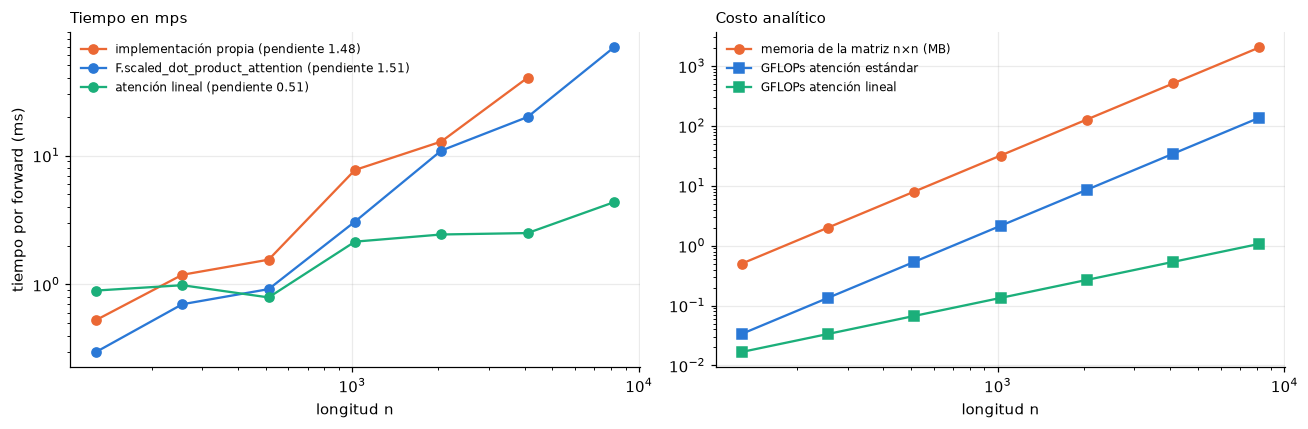

In [8]:
def atencion_lineal(Q, K, V):
    phi_q, phi_k = F.elu(Q) + 1, F.elu(K) + 1
    kv = phi_k.transpose(-2, -1) @ V                            # (d, d): no depende de n
    z = 1 / (phi_q @ phi_k.sum(-2, keepdim=True).transpose(-2, -1) + 1e-6)
    return (phi_q @ kv) * z

def medir(fn, reps=5):
    fn(); sincronizar()
    tiempos = []
    for _ in range(reps):
        t0 = time.perf_counter(); fn(); sincronizar(); tiempos.append(time.perf_counter() - t0)
    return float(np.median(tiempos)) * 1000

LONGITUDES = [64, 128, 256] if SMOKE else [128, 256, 512, 1024, 2048, 4096, 8192]
MAX_INGENUA = 256 if SMOKE else 4096
Bb, Hh, Dd = 1, 8, 64
filas = []
for n in LONGITUDES:
    Q, K, Vv = (torch.randn(Bb, Hh, n, Dd, device=DISP) for _ in range(3))
    fila = {"n": n,
            "sdpa_ms": medir(lambda: F.scaled_dot_product_attention(Q, K, Vv)),
            "lineal_ms": medir(lambda: atencion_lineal(Q, K, Vv)),
            "ingenua_ms": medir(lambda: atencion(Q, K, Vv)) if n <= MAX_INGENUA else float("nan"),
            "memoria_matriz_mb": Bb * Hh * n * n * 4 / 2**20,
            "memoria_lineal_mb": Bb * Hh * Dd * Dd * 4 / 2**20,
            "gflops_estandar": 4 * Bb * Hh * n * n * Dd / 1e9,
            "gflops_lineal": 4 * Bb * Hh * n * Dd * Dd / 1e9}
    filas.append(fila)
    print({k: (round(v, 3) if isinstance(v, float) else v) for k, v in fila.items()}, flush=True)
    del Q, K, Vv
tabla_esc = pd.DataFrame(filas)
tabla_esc.to_csv("results/escalamiento.csv", index=False)

def pendiente(col):
    t = tabla_esc.dropna(subset=[col]); t = t[t.n >= 512] if (t.n >= 512).sum() >= 3 else t
    return float(np.polyfit(np.log(t.n), np.log(t[col]), 1)[0])
PENDIENTES = {c: pendiente(c) for c in ["ingenua_ms", "sdpa_ms", "lineal_ms"]}
json.dump(PENDIENTES, open("results/pendientes_escalamiento.json", "w"), indent=1)
print("pendientes log-log del tiempo:", {k: round(v, 2) for k, v in PENDIENTES.items()})

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
for col, etq, c in [("ingenua_ms", "implementación propia", NARANJA), ("sdpa_ms", "F.scaled_dot_product_attention", AZUL),
                    ("lineal_ms", "atención lineal", VERDE)]:
    a1.loglog(tabla_esc.n, tabla_esc[col], marker="o", color=c, label=f"{etq} (pendiente {PENDIENTES[col]:.2f})")
a1.set_xlabel("longitud n"); a1.set_ylabel("tiempo por forward (ms)")
a1.set_title(f"Tiempo en {DISP.type}", loc="left", fontsize=10); a1.legend(fontsize=8, frameon=False)
a2.loglog(tabla_esc.n, tabla_esc.memoria_matriz_mb, marker="o", color=NARANJA, label="memoria de la matriz n×n (MB)")
a2.loglog(tabla_esc.n, tabla_esc.gflops_estandar, marker="s", color=AZUL, label="GFLOPs atención estándar")
a2.loglog(tabla_esc.n, tabla_esc.gflops_lineal, marker="s", color=VERDE, label="GFLOPs atención lineal")
a2.set_xlabel("longitud n"); a2.set_title("Costo analítico", loc="left", fontsize=10); a2.legend(fontsize=8, frameon=False)
fig.tight_layout(); fig.savefig("figs/escalamiento.png", bbox_inches="tight"); plt.show()

## 3. Atención en modelos preentrenados

Se cargan los modelos exactamente como indica el enunciado, con `attn_implementation="eager"` para que devuelvan las matrices de atención. `outputs.attentions` es una tupla con un tensor por capa de forma `(batch, cabezas, n, n)`, donde la fila $i$ es la distribución de atención del token $i$ sobre todos los tokens.

In [9]:
t0 = time.time()
tok_bert = AutoTokenizer.from_pretrained("bert-base-uncased")
bert = AutoModel.from_pretrained("bert-base-uncased", output_attentions=True, attn_implementation="eager").eval()
tok_gpt2 = AutoTokenizer.from_pretrained("gpt2")
gpt2 = AutoModel.from_pretrained("gpt2", output_attentions=True, attn_implementation="eager").eval()
gpt2_lm = AutoModelForCausalLM.from_pretrained("gpt2", attn_implementation="eager").eval()
print(f"modelos cargados en {time.time() - t0:.0f} s")

@torch.no_grad()
def atenciones(modelo, tok, texto, prefijo=""):
    enc = tok(prefijo + texto, return_tensors="pt")
    salida = modelo(**enc)
    A = torch.stack(salida.attentions)[:, 0].float().numpy()          # (capas, cabezas, n, n)
    tokens = [t.replace("Ġ", "") for t in tok.convert_ids_to_tokens(enc["input_ids"][0])]
    return tokens, A

tokens, A = atenciones(bert, tok_bert, "The cat sat on the mat.")
print("BERT: capas y cabezas", (bert.config.num_hidden_layers, bert.config.num_attention_heads), "| forma por capa:", A.shape[1:], "| tokens:", tokens)
tokens, A = atenciones(gpt2, tok_gpt2, "The cat sat on the mat.")
print("GPT-2: capas y cabezas", (gpt2.config.n_layer, gpt2.config.n_head), "| forma por capa:", A.shape[1:], "| tokens:", tokens)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

modelos cargados en 174 s
BERT: capas y cabezas (12, 12) | forma por capa: (12, 9, 9) | tokens: ['[CLS]', 'the', 'cat', 'sat', 'on', 'the', 'mat', '.', '[SEP]']
GPT-2: capas y cabezas (12, 12) | forma por capa: (12, 7, 7) | tokens: ['The', 'cat', 'sat', 'on', 'the', 'mat', '.']


### 3.1 Patrones por cabeza y mapas de calor

In [10]:
FRASE = "The cat sat on the mat, and then it looked at the dog."
FRASES = [
    "The cat sat on the mat, and then it looked at the dog.",
    "Scientists discovered a new species of frog in the rainforest last year.",
    "She opened the door, turned on the light, and found the room empty.",
    "The stock market fell sharply after the bank announced its losses.",
    "If it rains tomorrow, we will stay at home and watch a movie.",
    "The old man told his grandson a story about the war.",
    "Paris is the capital of France, and Berlin is the capital of Germany.",
    "After the game, the players thanked the fans for their support.",
]
PUNT = set(".,;:!?'\"()-")

def patrones(tokens, A, causal):
    n = A.shape[-1]
    filas = np.arange(1, n) if causal else np.arange(n)       # en GPT-2 la fila 0 solo puede verse a sí misma
    r = {}
    i = filas[filas >= 1]
    r["token anterior"] = A[:, :, i, i - 1].mean(-1)
    if not causal:
        i = filas[filas < n - 1]
        r["token siguiente"] = A[:, :, i, i + 1].mean(-1)
        r["[CLS]"] = A[:, :, filas, 0].mean(-1)
        r["[SEP]"] = A[:, :, filas, n - 1].mean(-1)
    else:
        r["primer token"] = A[:, :, filas, 0].mean(-1)
    p = [j for j, t in enumerate(tokens) if t in PUNT]
    r["puntuación"] = A[:, :, filas][:, :, :, p].sum(-1).mean(-1) if p else np.zeros(A.shape[:2])
    r["misma palabra"] = A[:, :, filas, filas].mean(-1)
    return r

def patrones_promedio(modelo, tok, causal):
    acum = None
    for f in FRASES:
        tokens, A = atenciones(modelo, tok, f)
        r = patrones(tokens, A, causal)
        acum = r if acum is None else {k: acum[k] + r[k] for k in r}
    return {k: v / len(FRASES) for k, v in acum.items()}

PAT = {"BERT": patrones_promedio(bert, tok_bert, False), "GPT-2": patrones_promedio(gpt2, tok_gpt2, True)}
filas = []
for m, r in PAT.items():
    for patron, S in r.items():
        l, h = np.unravel_index(S.argmax(), S.shape)
        filas.append({"modelo": m, "patron": patron, "capa": int(l) + 1, "cabeza": int(h) + 1,
                      "puntaje_max": float(S.max()), "promedio_todas": float(S.mean()),
                      "cabezas_sobre_0.5": int((S > 0.5).sum())})
tabla_pat = pd.DataFrame(filas)
tabla_pat.to_csv("results/patrones_cabezas.csv", index=False)
tabla_pat.round(3)

,modelo,patron,capa,cabeza,puntaje_max,promedio_todas,cabezas_sobre_0.5
0,BERT,token anterior,4,6,0.651,0.074,2
1,BERT,token siguiente,3,10,0.932,0.098,5
2,BERT,[CLS],2,7,0.892,0.125,4
3,BERT,[SEP],6,2,0.852,0.338,46
4,BERT,puntuación,11,2,0.792,0.150,17
5,BERT,misma palabra,3,7,0.401,0.096,0
6,GPT-2,token anterior,5,12,0.999,0.164,2
7,GPT-2,primer token,8,3,0.991,0.623,102
8,GPT-2,puntuación,3,6,0.165,0.035,0
9,GPT-2,misma palabra,1,2,0.923,0.089,4


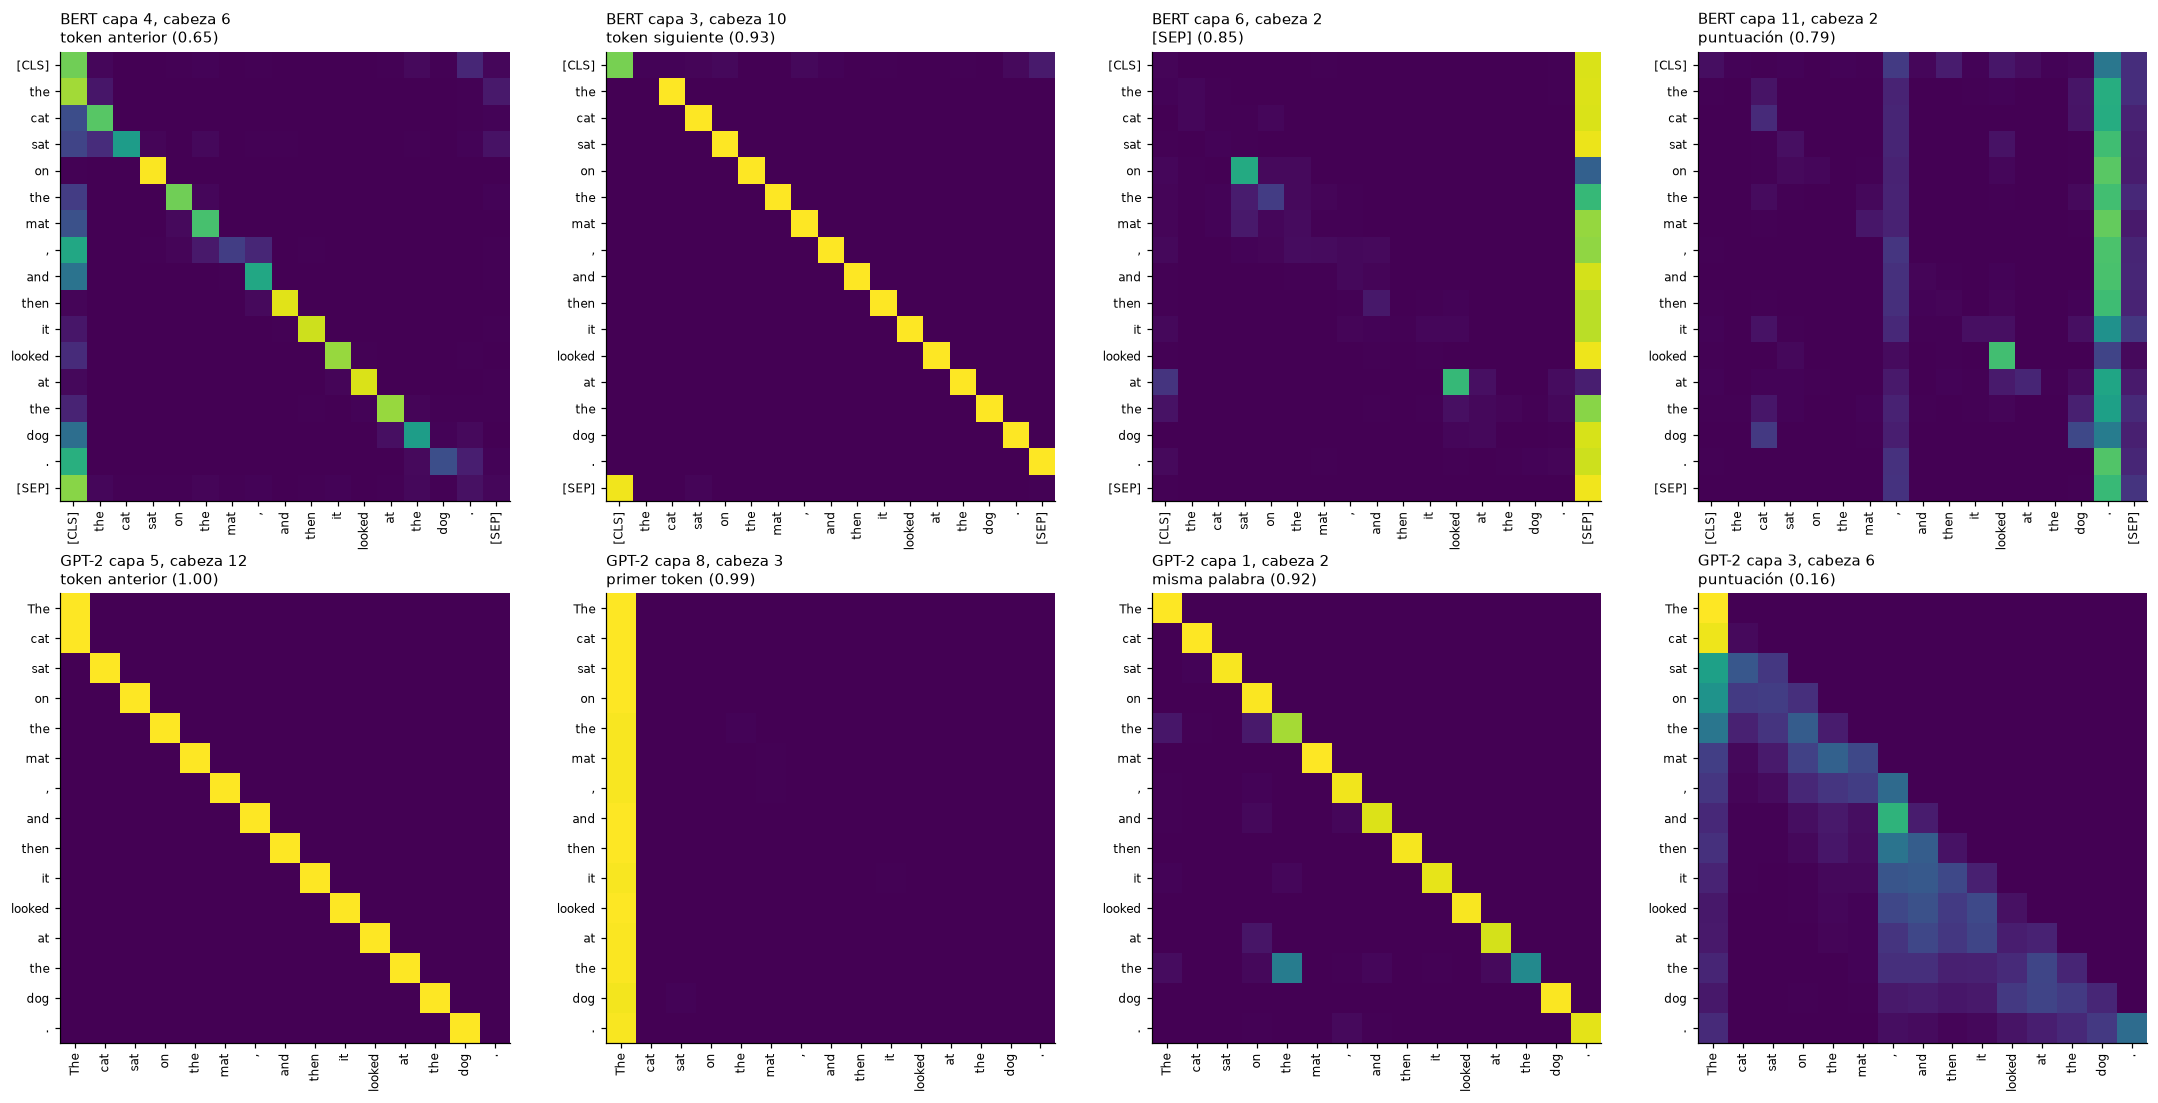

In [11]:
def elegir(r, orden):
    # mejor cabeza por patrón, cada una en una capa distinta
    usadas, out = set(), []
    for patron in orden:
        S = r[patron].copy()
        for l in usadas:
            S[l] = -1
        l, h = np.unravel_index(S.argmax(), S.shape)
        usadas.add(l); out.append((patron, int(l), int(h), float(r[patron][l, h])))
    return out

ELEGIDAS = {"BERT": elegir(PAT["BERT"], ["token anterior", "token siguiente", "[SEP]", "puntuación"]),
            "GPT-2": elegir(PAT["GPT-2"], ["token anterior", "primer token", "misma palabra", "puntuación"])}
fig, axs = plt.subplots(2, 4, figsize=(20, 10))
for fila, (m, modelo, tok) in enumerate([("BERT", bert, tok_bert), ("GPT-2", gpt2, tok_gpt2)]):
    tokens, A = atenciones(modelo, tok, FRASE)
    for col, (patron, l, h, s) in enumerate(ELEGIDAS[m]):
        ax = axs[fila, col]
        ax.imshow(A[l, h], cmap="viridis", vmin=0, vmax=1)
        ax.set_xticks(range(len(tokens))); ax.set_xticklabels(tokens, rotation=90, fontsize=8)
        ax.set_yticks(range(len(tokens))); ax.set_yticklabels(tokens, fontsize=8)
        ax.set_title(f"{m} capa {l + 1}, cabeza {h + 1}\n{patron} ({s:.2f})", fontsize=10, loc="left")
        ax.grid(False)
fig.tight_layout(); fig.savefig("figs/mapas_atencion.png", bbox_inches="tight"); plt.show()
json.dump({m: [dict(zip(["patron", "capa", "cabeza", "puntaje"], (p, l + 1, h + 1, s))) for p, l, h, s in v] for m, v in ELEGIDAS.items()},
          open("results/cabezas_mapas.json", "w"), indent=1)

### 3.2 ¿A qué atiende «it»?

En «The animal didn't cross the street because it was too tired» el pronombre se refiere a *animal*, y en «… too wide» a *street*. Se buscan cabezas en las que «it» atienda más a *animal* en la primera oración y más a *street* en la segunda; el margen de una cabeza es el menor de los dos márgenes.

BERT: 22 de 144 cabezas cumplen la condición
 capa  cabeza  tired_animal  tired_street  wide_animal  wide_street  margen
    7      11         0.284         0.067        0.012        0.590   0.217
    9       5         0.242         0.014        0.046        0.209   0.163
    9       8         0.205         0.050        0.061        0.194   0.133
    5      11         0.333         0.095        0.167        0.288   0.121
    7       5         0.239         0.134        0.081        0.251   0.105 

GPT-2: 0 de 144 cabezas cumplen la condición
 capa  cabeza  tired_animal  tired_street  wide_animal  wide_street  margen
    5      12         0.000         0.000        0.000        0.000    -0.0
   11       3         0.004         0.004        0.004        0.004    -0.0
    6       2         0.000         0.000        0.000        0.000    -0.0
    8       3         0.001         0.001        0.001        0.001    -0.0
   11       2         0.004         0.004        0.004        0.004    -

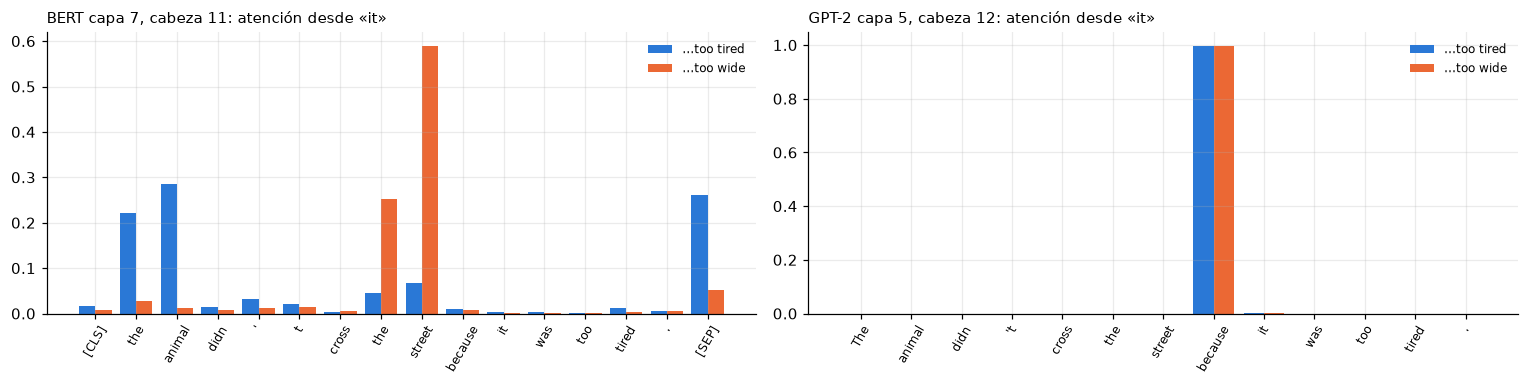

In [12]:
T_CANSADO = "The animal didn't cross the street because it was too tired."
T_ANCHO = "The animal didn't cross the street because it was too wide."
correferencia = {}
for m, modelo, tok in [("BERT", bert, tok_bert), ("GPT-2", gpt2, tok_gpt2)]:
    t1, A1 = atenciones(modelo, tok, T_CANSADO)
    t2, A2 = atenciones(modelo, tok, T_ANCHO)
    it, an, st = t1.index("it"), t1.index("animal"), t1.index("street")
    a1, s1, a2, s2 = A1[:, :, it, an], A1[:, :, it, st], A2[:, :, it, an], A2[:, :, it, st]
    margen = np.minimum(a1 - s1, s2 - a2)
    orden = np.dstack(np.unravel_index(np.argsort(-margen.ravel()), margen.shape))[0][:5]
    correferencia[m] = {
        "tokens": t1, "cabezas_que_cumplen": int((margen > 0).sum()), "total_cabezas": int(margen.size),
        "top": [{"capa": int(l) + 1, "cabeza": int(h) + 1, "tired_animal": float(a1[l, h]), "tired_street": float(s1[l, h]),
                 "wide_animal": float(a2[l, h]), "wide_street": float(s2[l, h]), "margen": float(margen[l, h])} for l, h in orden],
        "promedio_capas": {"tired_animal": float(a1.mean()), "tired_street": float(s1.mean()),
                           "wide_animal": float(a2.mean()), "wide_street": float(s2.mean())},
    }
    correferencia[m]["mejor"] = (int(orden[0][0]), int(orden[0][1]))
    print(f"{m}: {correferencia[m]['cabezas_que_cumplen']} de {margen.size} cabezas cumplen la condición")
    print(pd.DataFrame(correferencia[m]["top"]).round(3).to_string(index=False), "\n")
json.dump({m: {k: v for k, v in d.items() if k != "mejor"} for m, d in correferencia.items()},
          open("results/correferencia_it.json", "w"), indent=1)

fig, axs = plt.subplots(1, 2, figsize=(14, 3.6))
for ax, (m, modelo, tok) in zip(axs, [("BERT", bert, tok_bert), ("GPT-2", gpt2, tok_gpt2)]):
    l, h = correferencia[m]["mejor"]
    t1, A1 = atenciones(modelo, tok, T_CANSADO); _, A2 = atenciones(modelo, tok, T_ANCHO)
    it = t1.index("it"); x = np.arange(len(t1))
    ax.bar(x - 0.2, A1[l, h, it], 0.4, color=AZUL, label="…too tired")
    ax.bar(x + 0.2, A2[l, h, it], 0.4, color=NARANJA, label="…too wide")
    ax.set_xticks(x); ax.set_xticklabels(t1, rotation=60, fontsize=8)
    ax.set_title(f"{m} capa {l + 1}, cabeza {h + 1}: atención desde «it»", loc="left", fontsize=10)
    ax.legend(fontsize=8, frameon=False)
fig.tight_layout(); fig.savefig("figs/correferencia_it.png", bbox_inches="tight"); plt.show()

### 3.3 Máscara causal de GPT-2 y attention sinks

GPT-2 aplica una máscara causal, así que su matriz de atención debe ser triangular inferior. Se mide la proporción de atención que recibe el primer token en cada capa (sin contar la fila 0, que solo puede verse a sí misma) y se repite anteponiendo `<|endoftext|>` para ver si el efecto depende de la palabra o de la posición. En BERT se mide lo mismo para `[CLS]`, `[SEP]` y la puntuación.

In [13]:
max_arriba, filas_suman = 0.0, 0.0
prim, prim_bos, primera_palabra_bos = [], [], []
for f in FRASES:
    _, A = atenciones(gpt2, tok_gpt2, f)
    max_arriba = max(max_arriba, float(np.triu(A, k=1).max()))
    filas_suman = max(filas_suman, float(np.abs(A.sum(-1) - 1).max()))
    prim.append(A[:, :, 1:, 0].mean((1, 2)))
    _, Ab = atenciones(gpt2, tok_gpt2, f, prefijo=tok_gpt2.bos_token)
    prim_bos.append(Ab[:, :, 1:, 0].mean((1, 2)))
    primera_palabra_bos.append(Ab[:, :, 2:, 1].mean((1, 2)))
L = len(prim[0])
sinks = pd.DataFrame({"capa": range(1, L + 1), "primer_token": np.mean(prim, 0),
                      "bos_con_prefijo": np.mean(prim_bos, 0), "primera_palabra_con_prefijo": np.mean(primera_palabra_bos, 0)})
cls, sep, pun = [], [], []
for f in FRASES:
    tokens, A = atenciones(bert, tok_bert, f)
    p = [j for j, t in enumerate(tokens) if t in PUNT and j != len(tokens) - 1]
    cls.append(A[:, :, :, 0].mean((1, 2))); sep.append(A[:, :, :, -1].mean((1, 2)))
    pun.append(A[:, :, :, p].sum(-1).mean((1, 2)))
sinks["bert_cls"], sinks["bert_sep"], sinks["bert_puntuacion"] = np.mean(cls, 0), np.mean(sep, 0), np.mean(pun, 0)
sinks.to_csv("results/attention_sinks.csv", index=False)
json.dump({"max_peso_arriba_diagonal": max_arriba, "max_error_suma_filas": filas_suman},
          open("results/gpt2_triangular.json", "w"), indent=1)
print(f"GPT-2: peso máximo por encima de la diagonal = {max_arriba:.2e}; error máximo en la suma de filas = {filas_suman:.2e}")
sinks.round(3)

GPT-2: peso máximo por encima de la diagonal = 0.00e+00; error máximo en la suma de filas = 2.38e-07


,capa,primer_token,bos_con_prefijo,primera_palabra_con_prefijo,bert_cls,bert_sep,bert_puntuacion
0,1,0.237,0.276,0.083,0.138,0.070,0.094
1,2,0.394,0.395,0.079,0.419,0.084,0.096
2,3,0.387,0.327,0.075,0.346,0.094,0.087
3,4,0.539,0.524,0.054,0.258,0.215,0.081
4,5,0.566,0.548,0.047,0.049,0.503,0.053
5,6,0.745,0.740,0.029,0.035,0.576,0.046
6,7,0.717,0.708,0.033,0.037,0.557,0.047
7,8,0.804,0.819,0.018,0.025,0.571,0.069
8,9,0.735,0.736,0.029,0.028,0.569,0.059
9,10,0.822,0.821,0.019,0.067,0.532,0.082


### 3.4 Entropía de la atención por capa

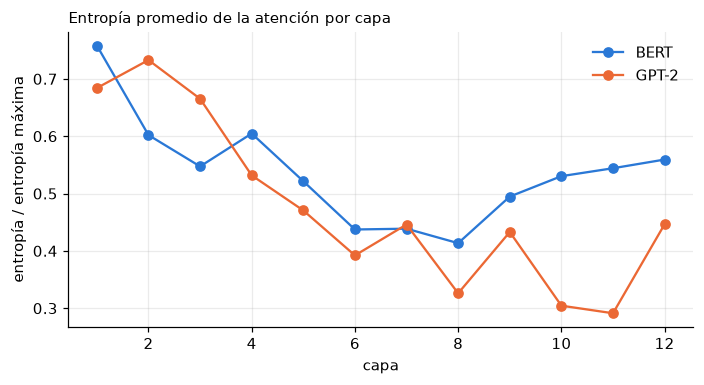

,capa,BERT_normalizada,BERT_nats,GPT-2_normalizada,GPT-2_nats
0,1,0.758,2.094,0.684,1.347
1,2,0.602,1.662,0.733,1.490
2,3,0.547,1.511,0.665,1.333
3,4,0.605,1.669,0.532,1.061
4,5,0.522,1.441,0.471,0.946
5,6,0.437,1.208,0.392,0.784
6,7,0.439,1.212,0.446,0.898
7,8,0.414,1.141,0.326,0.657
8,9,0.495,1.365,0.433,0.863
9,10,0.530,1.462,0.304,0.608


In [14]:
def entropias(modelo, tok, causal):
    norm, nats = [], []
    for f in FRASES:
        _, A = atenciones(modelo, tok, f)
        n = A.shape[-1]
        Hrow = -(A * np.log(np.clip(A, 1e-12, 1))).sum(-1)          # (capas, cabezas, n)
        if causal:
            Hrow, maximo = Hrow[:, :, 1:], np.log(np.arange(2, n + 1))
        else:
            maximo = np.log(n)
        norm.append((Hrow / maximo).mean((1, 2))); nats.append(Hrow.mean((1, 2)))
    return np.mean(norm, 0), np.mean(nats, 0)

ent = {}
for m, modelo, tok, causal in [("BERT", bert, tok_bert, False), ("GPT-2", gpt2, tok_gpt2, True)]:
    ent[f"{m}_normalizada"], ent[f"{m}_nats"] = entropias(modelo, tok, causal)
tabla_ent = pd.DataFrame({"capa": range(1, L + 1), **ent})
tabla_ent.to_csv("results/entropia_por_capa.csv", index=False)
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(tabla_ent.capa, tabla_ent["BERT_normalizada"], marker="o", color=AZUL, label="BERT")
ax.plot(tabla_ent.capa, tabla_ent["GPT-2_normalizada"], marker="o", color=NARANJA, label="GPT-2")
ax.set_xlabel("capa"); ax.set_ylabel("entropía / entropía máxima")
ax.set_title("Entropía promedio de la atención por capa", loc="left", fontsize=10); ax.legend(frameon=False)
fig.tight_layout(); fig.savefig("figs/entropia_por_capa.png", bbox_inches="tight"); plt.show()
tabla_ent.round(3)

### 3.5 ¿Todas las cabezas son útiles?

Se apaga una cabeza a la vez de GPT-2 poniendo en cero su salida antes de la proyección `c_proj` de su capa, y se mide cuánto sube la pérdida de modelado de lenguaje sobre las frases de prueba.

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


ablación de 144 cabezas en 7 s
{
 "perdida_base": 3.3434526920318604,
 "cabezas": 144,
 "cabezas_aumento_menor_1pct": 126,
 "cabezas_que_mejoran": 52,
 "max_aumento": 1.7515366077423096,
 "max_aumento_relativo": 0.5238706119325641,
 "top5": [
  {
   "capa": 1,
   "cabeza": 1,
   "aumento": 1.7515366077423096
  },
  {
   "capa": 1,
   "cabeza": 11,
   "aumento": 1.1746337413787842
  },
  {
   "capa": 6,
   "cabeza": 2,
   "aumento": 0.24971795082092285
  },
  {
   "capa": 1,
   "cabeza": 6,
   "aumento": 0.20535898208618164
  },
  {
   "capa": 4,
   "cabeza": 1,
   "aumento": 0.1028904914855957
  }
 ]
}


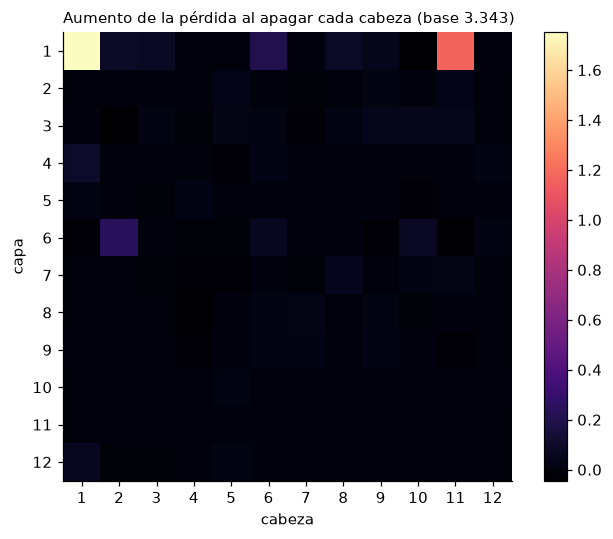

In [15]:
texto_lm = " ".join(FRASES)
enc_lm = tok_gpt2(texto_lm, return_tensors="pt")
@torch.no_grad()
def perdida_lm():
    return float(gpt2_lm(**enc_lm, labels=enc_lm["input_ids"]).loss)
base = perdida_lm()
Lg, Hg = gpt2_lm.config.n_layer, gpt2_lm.config.n_head
dh = gpt2_lm.config.n_embd // Hg
delta = np.zeros((Lg, Hg))
t0 = time.time()
for l in range(Lg):
    for h in range(Hg):
        def apagar(mod, args, h=h):
            x = args[0].clone(); x[..., h * dh:(h + 1) * dh] = 0
            return (x,)
        gancho = gpt2_lm.transformer.h[l].attn.c_proj.register_forward_pre_hook(apagar)
        delta[l, h] = perdida_lm() - base
        gancho.remove()
np.save("results/ablacion_cabezas_gpt2.npy", delta)
rel = delta / base
resumen_abl = {"perdida_base": base, "cabezas": int(delta.size),
               "cabezas_aumento_menor_1pct": int((rel < 0.01).sum()), "cabezas_que_mejoran": int((delta < 0).sum()),
               "max_aumento": float(delta.max()), "max_aumento_relativo": float(rel.max()),
               "top5": [{"capa": int(l) + 1, "cabeza": int(h) + 1, "aumento": float(delta[l, h])}
                        for l, h in np.dstack(np.unravel_index(np.argsort(-delta.ravel()), delta.shape))[0][:5]]}
json.dump(resumen_abl, open("results/ablacion_resumen.json", "w"), indent=1)
print(f"ablación de {delta.size} cabezas en {time.time() - t0:.0f} s"); print(json.dumps(resumen_abl, indent=1))

fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(delta, cmap="magma")
ax.set_xticks(range(Hg)); ax.set_xticklabels(range(1, Hg + 1)); ax.set_yticks(range(Lg)); ax.set_yticklabels(range(1, Lg + 1))
ax.set_xlabel("cabeza"); ax.set_ylabel("capa"); ax.grid(False)
ax.set_title(f"Aumento de la pérdida al apagar cada cabeza (base {base:.3f})", loc="left", fontsize=10)
fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout(); fig.savefig("figs/ablacion_cabezas.png", bbox_inches="tight"); plt.show()

### 3.6 ¿La atención explica la predicción?

Para frases incompletas se compara, token por token, la atención desde la última posición (promedio de las cabezas de la última capa y de todas las capas) contra la saliencia gradiente × entrada del logit del token predicho. Una correlación baja indica que los pesos de atención no coinciden con lo que más influye en la salida.

In [16]:
FRASES_PRED = [
    "The animal didn't cross the street because it was too",
    "The capital of France is",
    "She opened the door, turned on the light, and",
    "After the game, the players thanked the",
    "The stock market fell sharply after the bank",
    "If it rains tomorrow, we will stay at",
]
gpt2_lm.requires_grad_(False)                              # solo se necesita el gradiente de la entrada
filas = []
for s in FRASES_PRED:
    enc = tok_gpt2(s, return_tensors="pt")
    emb = gpt2_lm.transformer.wte(enc["input_ids"]).detach().requires_grad_(True)
    out = gpt2_lm(inputs_embeds=emb, output_attentions=True)
    pred = int(out.logits[0, -1].argmax())
    out.logits[0, -1, pred].backward()
    sal = (emb.grad[0] * emb[0].detach()).norm(dim=-1).numpy()
    att_ult = out.attentions[-1][0, :, -1, :].mean(0).detach().numpy()
    att_todas = torch.stack([a[0, :, -1, :].mean(0) for a in out.attentions]).mean(0).detach().numpy()
    toks = [t.replace("Ġ", "") for t in tok_gpt2.convert_ids_to_tokens(enc["input_ids"][0])]
    filas.append({"frase": s, "prediccion": tok_gpt2.decode([pred]).strip(),
                  "spearman_ultima_capa": float(spearmanr(att_ult, sal).correlation),
                  "spearman_todas_capas": float(spearmanr(att_todas, sal).correlation),
                  "spearman_sin_primer_token": float(spearmanr(att_todas[1:], sal[1:]).correlation),
                  "mas_atendido": toks[int(att_todas.argmax())], "mas_saliente": toks[int(sal.argmax())],
                  "atencion_al_primer_token": float(att_todas[0])})
tabla_exp = pd.DataFrame(filas)
tabla_exp.to_csv("results/atencion_vs_saliencia.csv", index=False)
tabla_exp.round(3)

,frase,prediccion,spearman_ultima_capa,spearman_todas_capas,spearman_sin_primer_token,mas_atendido,mas_saliente,atencion_al_primer_token
0,The animal didn't cross the street because it ...,scared,-0.064,0.073,-0.042,The,too,0.554
1,The capital of France is,the,-0.900,-0.400,0.200,The,is,0.650
2,"She opened the door, turned on the light, and",walked,0.300,-0.036,-0.152,She,and,0.524
3,"After the game, the players thanked the",players,-0.333,-0.024,-0.143,After,game,0.564
4,The stock market fell sharply after the bank,'s,-0.238,-0.024,-0.107,The,bank,0.641
5,"If it rains tomorrow, we will stay at",the,0.417,-0.033,0.024,If,rains,0.571


In [17]:
# bertviz es opcional: pip install bertviz
try:
    from bertviz import head_view
    tokens, _ = atenciones(bert, tok_bert, T_CANSADO)
    enc = tok_bert(T_CANSADO, return_tensors="pt")
    with torch.no_grad():
        head_view(bert(**enc).attentions, tokens)
except ImportError:
    print("bertviz no está instalado; las visualizaciones anteriores cubren lo pedido")

bertviz no está instalado; las visualizaciones anteriores cubren lo pedido
